
N = 20
narrow prior: m0=0.0, s0^2=0.0400  ->  posterior mean=0.9382, posterior var=0.026087
broad  prior: m0=0.0, s0^2=100.0000   ->  posterior mean=2.6953, posterior var=0.074944

N = 1000
narrow prior: m0=0.0, s0^2=0.0400  ->  posterior mean=1.8743, posterior var=0.001446
broad  prior: m0=0.0, s0^2=100.0000   ->  posterior mean=1.9445, posterior var=0.001500


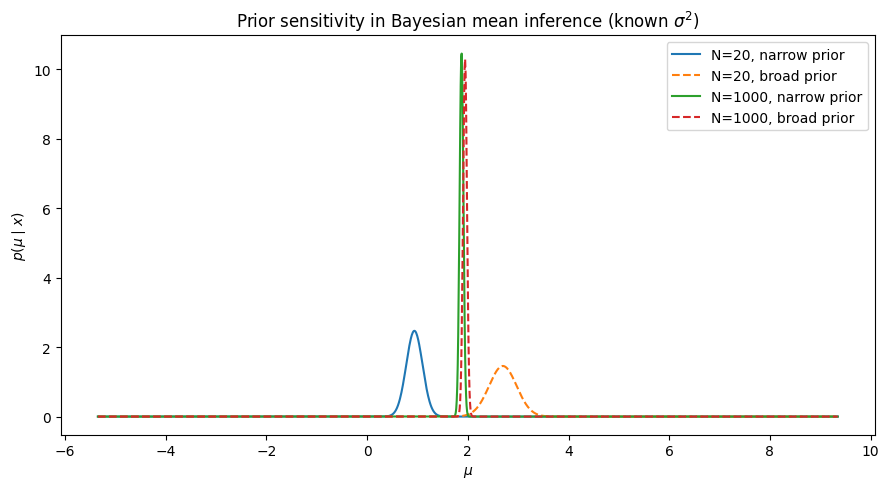

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# data: x ~ N(mu_true, sigma^2) with known sigma^2
mu_true = 2.0
sigma2 = 1.5
sigma = np.sqrt(sigma2)

def posterior_mu_known_sigma(x, sigma2, m0, s02):
    N = len(x)
    xbar = x.mean()
    sN2 = 1.0 / (1.0/s02 + N/sigma2)
    mN = sN2 * (m0/s02 + (N/sigma2)*xbar)
    return mN, sN2

# priors: same mean, different variance (narrow vs broad)
m0 = 0.0
s02_narrow = 0.2**2
s02_broad  = 10.0**2

# compare for small and large N
Ns = [20, 1000]

# generate a big pool once so the "same data set" is used when you take first N points
x_all = np.random.normal(mu_true, sigma, size=max(Ns))

for N in Ns:
    x = x_all[:N]

    mN_n, sN2_n = posterior_mu_known_sigma(x, sigma2, m0, s02_narrow)
    mN_b, sN2_b = posterior_mu_known_sigma(x, sigma2, m0, s02_broad)

    print(f"\nN = {N}")
    print(f"narrow prior: m0={m0}, s0^2={s02_narrow:.4f}  ->  posterior mean={mN_n:.4f}, posterior var={sN2_n:.6f}")
    print(f"broad  prior: m0={m0}, s0^2={s02_broad:.4f}   ->  posterior mean={mN_b:.4f}, posterior var={sN2_b:.6f}")

# optional: visualize posterior Gaussians for the two priors at each N
mu_grid = np.linspace(mu_true - 6*sigma, mu_true + 6*sigma, 1500)

plt.figure(figsize=(9, 5))
for i, N in enumerate(Ns, start=1):
    x = x_all[:N]

    mN_n, sN2_n = posterior_mu_known_sigma(x, sigma2, m0, s02_narrow)
    mN_b, sN2_b = posterior_mu_known_sigma(x, sigma2, m0, s02_broad)

    # posterior densities (up to normalization constant of a Gaussian)
    pn = np.exp(-(mu_grid - mN_n)**2/(2*sN2_n)) / np.sqrt(2*np.pi*sN2_n)
    pb = np.exp(-(mu_grid - mN_b)**2/(2*sN2_b)) / np.sqrt(2*np.pi*sN2_b)

    plt.plot(mu_grid, pn, label=f"N={N}, narrow prior")
    plt.plot(mu_grid, pb, linestyle="--", label=f"N={N}, broad prior")

plt.xlabel(r"$\mu$")
plt.ylabel(r"$p(\mu \mid x)$")
plt.title("Prior sensitivity in Bayesian mean inference (known $\\sigma^2$)")
plt.legend()
plt.tight_layout()
plt.show()


Discussion:
Posterior precision adds: $1/s_N^2 = 1/s_0^2 + N/\sigma^2$.
So for small N, the prior term $1/s_0^2$ can be comparable to $N/\sigma^2$ (strong prior influence).
As N increases, $N/\sigma^2$ dominates, the posterior mean moves toward the sample mean,
and the posterior variance approaches $\sigma^2/N$ (prior influence becomes negligible).